=============================================================BANK CUSTOMER CHURN ANALYSIS ===========================================================

In [79]:
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as mp
import numpy as np
import csv 
from matplotlib.colors import LinearSegmentedColormap

In [2]:
df=pd.read_csv('Churn_Modelling.csv',encoding='unicode_escape')

In [3]:
df.shape 

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [90]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Balance'],
      dtype='object')

In [89]:
df.rename(columns={("Balance",): "Balance"}, inplace=True)

In [6]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [8]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Zero null values found in the dataset.So there is no use of drop () and dropna().

In [36]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance              int64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
(Balance,)           int64
dtype: object

Displays datatype of all columns in the table .

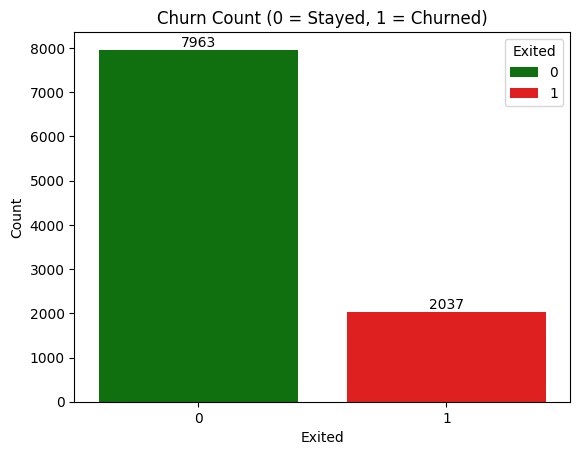

In [49]:
ax=sb.countplot(x="Exited", data=df, hue="Exited" ,palette=["green", "red"])
mp.title("Churn Count (0 = Stayed, 1 = Churned)")
mp.xlabel("Exited")
mp.ylabel("Count")
for bars in ax.containers:
    ax.bar_label(bars)
mp.show()


Above graph shows how many customers left the bank versus how many stayed.

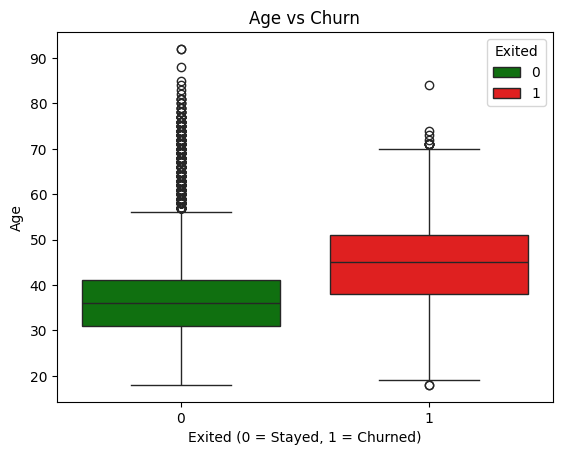

In [61]:
sb.boxplot(x="Exited", y="Age", data=df ,hue="Exited",palette=["green", "red"])
mp.title("Age vs Churn")
mp.xlabel("Exited (0 = Stayed, 1 = Churned)")
mp.ylabel("Age")
mp.show()

 Above graph shows that customers who left the bank are generally older than customers who stayed.

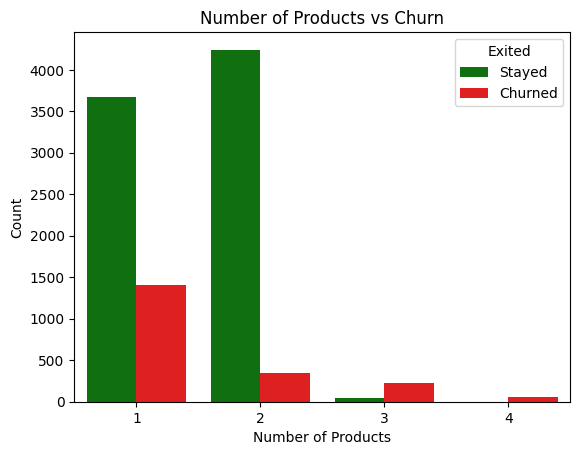

In [63]:
sb.countplot(x="NumOfProducts", hue="Exited", data=df, palette=["green", "red"])
mp.title("Number of Products vs Churn")
mp.xlabel("Number of Products")
mp.ylabel("Count")
mp.legend(title="Exited", labels=["Stayed", "Churned"])
mp.show()

 Above graph shows that customers with 3 or 4 products are more likely to leave compared to customers with 1 or 2 products.

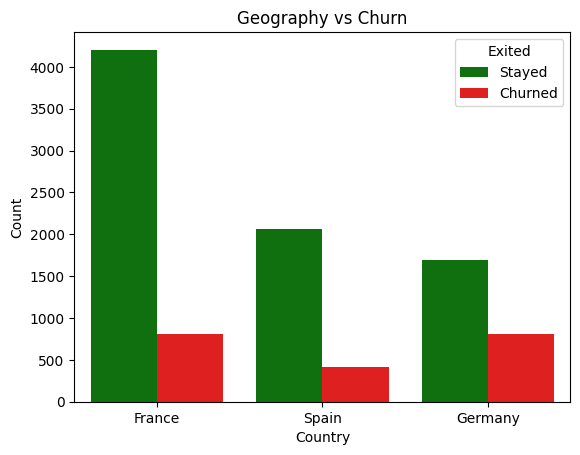

In [66]:
sb.countplot(x="Geography", hue="Exited", data=df, palette=["green", "red"])
mp.title("Geography vs Churn")
mp.xlabel("Country")
mp.ylabel("Count")
mp.legend(title="Exited", labels=["Stayed", "Churned"])
mp.show()

Above graph shows that customers from Germany leave the bank more often compared to France and Spain.

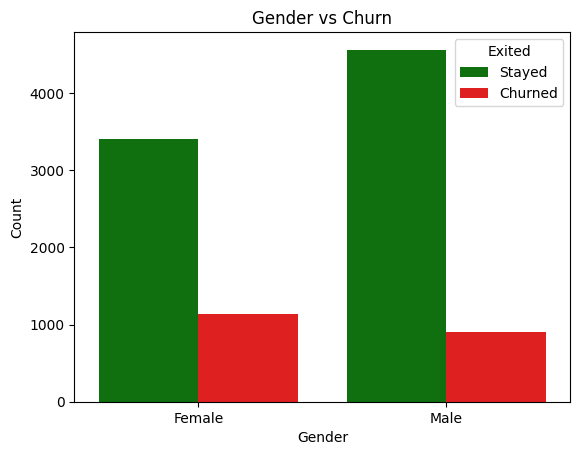

In [68]:
sb.countplot(x="Gender", hue="Exited", data=df, palette=["green", "red"])
mp.title("Gender vs Churn")
mp.xlabel("Gender")
mp.ylabel("Count")
mp.legend(title="Exited", labels=["Stayed", "Churned"])
mp.show()

Above graph shows that female customers leave the bank more often than male customers.

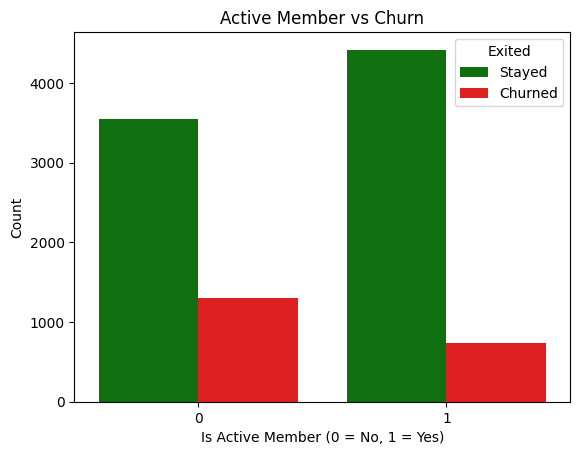

In [71]:
sb.countplot(x="IsActiveMember", hue="Exited", data=df, palette=["green", "red"])
mp.title("Active Member vs Churn")
mp.xlabel("Is Active Member (0 = No, 1 = Yes)")
mp.ylabel("Count")
mp.legend(title="Exited", labels=["Stayed", "Churned"])
mp.show()

Above graph shows that customers who are not active with the bank are more likely to leave.

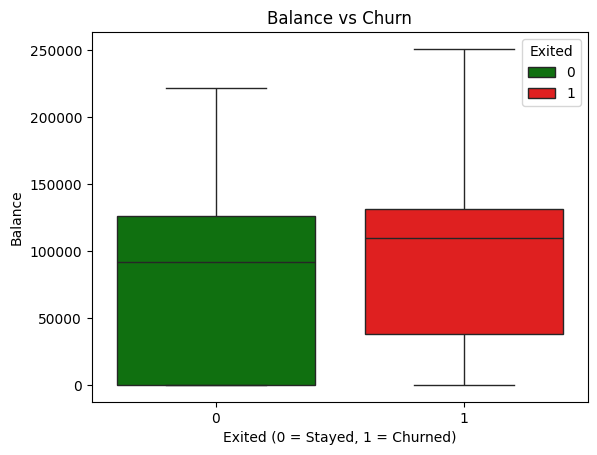

In [75]:
sb.boxplot(x="Exited", y="Balance", data=df,hue="Exited" ,palette=["green", "red"])
mp.title("Balance vs Churn")
mp.xlabel("Exited (0 = Stayed, 1 = Churned)")
mp.ylabel("Balance")
mp.show()

Above graph shows that customers who leave the bank has higher account balance than those who stayed.

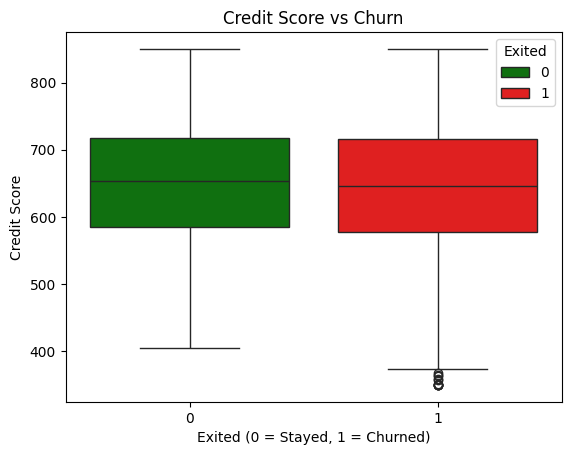

In [76]:
sb.boxplot(x="Exited", y="CreditScore", data=df, hue="Exited" ,palette=["green", "red"])
mp.title("Credit Score vs Churn")
mp.xlabel("Exited (0 = Stayed, 1 = Churned)")
mp.ylabel("Credit Score")
mp.show()

Above graph shows that credit score has very little difference between those who stayed and those who left . 

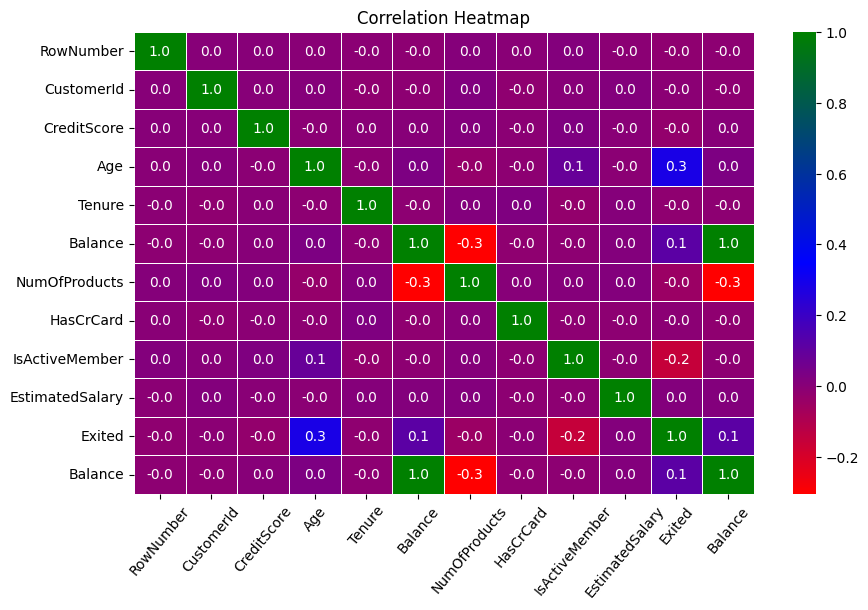

In [91]:
colors = ["red", "blue", "green"]
mp.figure(figsize=(10, 6))
my_cmap = LinearSegmentedColormap.from_list("mycolors", colors)
sb.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap=my_cmap, linewidths=0.5)
mp.title("Correlation Heatmap")
mp.xticks(rotation=50)
mp.show()

Above graph shows which features are related to each other and how strongly they are connected.

After looking at all the charts, here are the key insights:

Age — Older customers are more likely to leave the bank.
Number of Products — Customers with 3 or 4 products almost always leave.
Geography — Germany has the highest number of customers leaving.
Gender — Female customers leave more than male customers.
Active Member — Customers who don't use the bank actively tend to leave.
Balance — Customers with higher balance are more likely to leave.
Credit Score — Has no strong impact on whether a customer leaves or stays.

Overall, the bank should focus on age, number of products, geography, and active membership as these are the biggest reasons why customers are leaving.
